ONLY ASC

In [1]:
import pandas as pd
import biogeme.database as db
import biogeme.biogeme as bio
from biogeme.expressions import Beta
import biogeme.models as models

# Load the dataset with correct format
df = pd.read_csv("DataSetModel0NA6Alt.csv", sep=";", decimal=",")
database = db.Database("PenaltyData", df)

# Define variables
Choice = database.variables['Choice']

# ASCs (Alternative Specific Constants)
# Fix asc_DC to 0 (reference alternative)
asc_TL = Beta('asc_TL', 0, None, None, 0)
asc_TC = Beta('asc_TC', 0, None, None, 0)
asc_TR = Beta('asc_TR', 0, None, None, 0)
asc_DL = Beta('asc_DL', 0, None, None, 0)
asc_DR = Beta('asc_DR', 0, None, None, 0)
asc_DC = Beta('asc_DC', 0, None, None, 1)  # ✅ Fixed at 0

# Utility functions
V = {
    1: asc_TL,
    2: asc_TC,
    3: asc_TR,
    4: asc_DL,
    5: asc_DC,  # Reference alternative
    6: asc_DR
}

# Availability: all alternatives always available
av = {k: 1 for k in V}

# Define model: MNL
logprob = models.loglogit(V, av, Choice)

# Biogeme object
biogeme = bio.BIOGEME(database, logprob)
biogeme.modelName = "ASC_only_model_biogeme"

# Estimate model
results = biogeme.estimate()

# Show results
print(results.getEstimatedParameters())

           Value  Rob. Std err  Rob. t-test  Rob. p-value
asc_DL  1.696460      0.085749    19.784019      0.000000
asc_DR  1.529172      0.086953    17.586278      0.000000
asc_TC -0.199301      0.117489    -1.696338      0.089822
asc_TL  0.366454      0.102550     3.573408      0.000352
asc_TR  0.276371      0.104507     2.644512      0.008181


C:\Users\varsh\AppData\Local\Temp\ipykernel_16320\3998605578.py:47: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  print(results.getEstimatedParameters())


movegk + footdeness

In [2]:
import pandas as pd
import biogeme.database as db
import biogeme.biogeme as bio
from biogeme.expressions import Beta, Variable
import biogeme.models as models

# Load dataset
df = pd.read_csv("DataSetModel0NA6Alt.csv", sep=";", decimal=",")
database = db.Database("PenaltyData", df)

# Define variables
Choice = Variable('Choice')
foot = Variable('foot')
moveGK = Variable('moveGK')

# ASC parameters
ASC1 = Beta('ASC1', 0, None, None, 0)
ASC2 = Beta('ASC2', 0, None, None, 0)
ASC3 = Beta('ASC3', 0, None, None, 0)
ASC4 = Beta('ASC4', 0, None, None, 0)
ASC5 = Beta('ASC5', 0, None, None, 1)  # Fixed
ASC6 = Beta('ASC6', 0, None, None, 0)

# Alternative-specific betas for foot
B_foot1 = Beta('B_foot1', 0, None, None, 0)
B_foot2 = Beta('B_foot2', 0, None, None, 0)
B_foot3 = Beta('B_foot3', 0, None, None, 0)
B_foot4 = Beta('B_foot4', 0, None, None, 0)
B_foot5 = Beta('B_foot5', 0, None, None, 1)
B_foot6 = Beta('B_foot6', 0, None, None, 0)

# Alternative-specific betas for moveGK
B_moveGK1 = Beta('B_moveGK1', 0, None, None, 0)
B_moveGK2 = Beta('B_moveGK2', 0, None, None, 0)
B_moveGK3 = Beta('B_moveGK3', 0, None, None, 0)
B_moveGK4 = Beta('B_moveGK4', 0, None, None, 0)
B_moveGK5 = Beta('B_moveGK5', 0, None, None, 1)
B_moveGK6 = Beta('B_moveGK6', 0, None, None, 0)

# Utility functions (ASC + alternative-specific effects)
V = {
    1: ASC1 + B_foot1 * foot + B_moveGK1 * moveGK,
    2: ASC2 + B_foot2 * foot + B_moveGK2 * moveGK,
    3: ASC3 + B_foot3 * foot + B_moveGK3 * moveGK,
    4: ASC4 + B_foot4 * foot + B_moveGK4 * moveGK,
    5: ASC5 + B_foot5 * foot + B_moveGK5 * moveGK,  # DC (fixed ASC)
    6: ASC6 + B_foot6 * foot + B_moveGK6 * moveGK,
}

# All alternatives available
av = {1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1}

# MNL model
logprob = models.loglogit(V, av, Choice)

# Estimation
biogeme = bio.BIOGEME(database, logprob)
biogeme.modelName = 'alt_specific_foot_move_model'

results = biogeme.estimate()

# Output
print(results.getEstimatedParameters())


              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC1       0.091555      0.231790     0.394990  6.928503e-01
ASC2      -0.713937      0.286072    -2.495660  1.257232e-02
ASC3       0.774057      0.202420     3.824010  1.312985e-04
ASC4       1.368295      0.184608     7.411878  1.245670e-13
ASC6       1.721818      0.179929     9.569424  0.000000e+00
B_foot1    0.387376      0.249074     1.555262  1.198836e-01
B_foot2    0.591629      0.301001     1.965535  4.935235e-02
B_foot3   -0.677003      0.229558    -2.949155  3.186444e-03
B_foot4    0.299271      0.200406     1.493323  1.353526e-01
B_foot6   -0.263393      0.198198    -1.328939  1.838683e-01
B_moveGK1 -0.058763      0.104025    -0.564890  5.721484e-01
B_moveGK2  0.058114      0.115186     0.504517  6.138979e-01
B_moveGK3 -0.068163      0.106484    -0.640123  5.220927e-01
B_moveGK4  0.131514      0.085481     1.538519  1.239218e-01
B_moveGK6 -0.007431      0.086202    -0.086204  9.313045e-01


C:\Users\varsh\AppData\Local\Temp\ipykernel_16320\3399538501.py:63: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  print(results.getEstimatedParameters())


complete code

In [27]:
import pandas as pd
import biogeme.database as db
import biogeme.biogeme as bio
from biogeme.expressions import Beta, Variable
import biogeme.models as models

# Load dataset
df = pd.read_csv("DataSetModel0NA6Alt.csv", sep=";", decimal=",")
database = db.Database("PenaltyData", df)

# Choice variable
Choice = Variable('Choice')

# ASC parameters (DC reference: fixed to zero)
asc_TL = Beta('asc_TL', 0, None, None, 0)
asc_TC = Beta('asc_TC', 0, None, None, 0)
asc_TR = Beta('asc_TR', 0, None, None, 0)
asc_DL = Beta('asc_DL', 0, None, None, 0)
asc_DC = Beta('asc_DC', 0, None, None, 1)  # fixed reference
asc_DR = Beta('asc_DR', 0, None, None, 0)

# Foot parameters (DC fixed)
b_foot1 = Beta('b_foot1', 0, None, None, 0)
b_foot2 = Beta('b_foot2', 0, None, None, 0)
b_foot3 = Beta('b_foot3', 0, None, None, 0)
b_foot4 = Beta('b_foot4', 0, None, None, 0)
b_foot5 = Beta('b_foot5', 0, None, None, 1)  # fixed
b_foot6 = Beta('b_foot6', 0, None, None, 0)

# MoveGK parameters (DC fixed)
b_moveGK1 = Beta('b_moveGK1', 0, None, None, 0)
b_moveGK2 = Beta('b_moveGK2', 0, None, None, 0)
b_moveGK3 = Beta('b_moveGK3', 0, None, None, 0)
b_moveGK4 = Beta('b_moveGK4', 0, None, None, 0)
b_moveGK5 = Beta('b_moveGK5', 0, None, None, 1)  # fixed
b_moveGK6 = Beta('b_moveGK6', 0, None, None, 0)

# GKS parameters (DC fixed)
b_GKS1 = Beta('b_GKS1', 0, None, None, 0)
b_GKS2 = Beta('b_GKS2', 0, None, None, 0)
b_GKS3 = Beta('b_GKS3', 0, None, None, 0)
b_GKS4 = Beta('b_GKS4', 0, None, None, 0)
b_GKS5 = Beta('b_GKS5', 0, None, None, 1)  # fixed
b_GKS6 = Beta('b_GKS6', 0, None, None, 0)

# IS parameters (DC fixed)
b_IS1 = Beta('b_IS1', 0, None, None, 0)
b_IS2 = Beta('b_IS2', 0, None, None, 0)
b_IS3 = Beta('b_IS3', 0, None, None, 0)
b_IS4 = Beta('b_IS4', 0, None, None, 0)
b_IS5 = Beta('b_IS5', 0, None, None, 1)  # fixed
b_IS6 = Beta('b_IS6', 0, None, None, 0)

# comL parameters (DC fixed)
b_comL1 = Beta('b_comL1', 0, None, None, 0)
b_comL2 = Beta('b_comL2', 0, None, None, 0)
b_comL3 = Beta('b_comL3', 0, None, None, 0)
b_comL4 = Beta('b_comL4', 0, None, None, 0)
b_comL5 = Beta('b_comL5', 0, None, None, 1)  # fixed
b_comL6 = Beta('b_comL6', 0, None, None, 0)

# HeiGK parameters (DC fixed)
b_HGK1 = Beta('b_HGK1', 0, None, None, 0)
b_HGK2 = Beta('b_HGK2', 0, None, None, 0)
b_HGK3 = Beta('b_HGK3', 0, None, None, 0)
b_HGK4 = Beta('b_HGK4', 0, None, None, 0)
b_HGK5 = Beta('b_HGK5', 0, None, None, 1)  # fixed
b_HGK6 = Beta('b_HGK6', 0, None, None, 0)

# dec parameters (DC fixed)
b_dec1 = Beta('b_dec1', 0, None, None, 0)
b_dec2 = Beta('b_dec2', 0, None, None, 0)
b_dec3 = Beta('b_dec3', 0, None, None, 0)
b_dec4 = Beta('b_dec4', 0, None, None, 0)
b_dec5 = Beta('b_dec5', 0, None, None, 1)  # fixed
b_dec6 = Beta('b_dec6', 0, None, None, 0)

# lp parameters (DC fixed)
b_lp1 = Beta('b_lp1', 0, None, None, 0)
b_lp2 = Beta('b_lp2', 0, None, None, 0)
b_lp3 = Beta('b_lp3', 0, None, None, 0)
b_lp4 = Beta('b_lp4', 0, None, None, 0)
b_lp5 = Beta('b_lp5', 0, None, None, 1)  # fixed
b_lp6 = Beta('b_lp6', 0, None, None, 0)

# latr parameters (DC fixed)
b_latr1 = Beta('b_latr1', 0, None, None, 0)
b_latr2 = Beta('b_latr2', 0, None, None, 0)
b_latr3 = Beta('b_latr3', 0, None, None, 0)
b_latr4 = Beta('b_latr4', 0, None, None, 0)
b_latr5 = Beta('b_latr5', 0, None, None, 1)  # fixed
b_latr6 = Beta('b_latr6', 0, None, None, 0)

# ladr parameters (DC fixed)
b_ladr1 = Beta('b_ladr1', 0, None, None, 0)
b_ladr2 = Beta('b_ladr2', 0, None, None, 0)
b_ladr3 = Beta('b_ladr3', 0, None, None, 0)
b_ladr4 = Beta('b_ladr4', 0, None, None, 0)
b_ladr5 = Beta('b_ladr5', 0, None, None, 1)  # fixed
b_ladr6 = Beta('b_ladr6', 0, None, None, 0)

# sr parameters only for TL and TR (1 and 3)
b_sr1 = Beta('b_sr1', 0, None, None, 0)
b_sr3 = Beta('b_sr3', 0, None, None, 0)

# perc generic variable (shared across)
b_perc = Beta('b_perc', 0, None, None, 0)

# rnog parameters (DC fixed)
b_rnog1 = Beta('b_rnog1', 0, None, None, 0)
b_rnog2 = Beta('b_rnog2', 0, None, None, 0)
b_rnog3 = Beta('b_rnog3', 0, None, None, 0)
b_rnog4 = Beta('b_rnog4', 0, None, None, 0)
b_rnog5 = Beta('b_rnog5', 0, None, None, 1)  # fixed
b_rnog6 = Beta('b_rnog6', 0, None, None, 0)

# solsbg parameters (DC fixed)
b_solsbg1 = Beta('b_solsbg1', 0, None, None, 0)
b_solsbg2 = Beta('b_solsbg2', 0, None, None, 0)
b_solsbg3 = Beta('b_solsbg3', 0, None, None, 0)
b_solsbg4 = Beta('b_solsbg4', 0, None, None, 0)
b_solsbg5 = Beta('b_solsbg5', 0, None, None, 1)  # fixed
b_solsbg6 = Beta('b_solsbg6', 0, None, None, 0)

# nmovGK parameters (DC fixed)
b_nmovGK1 = Beta('b_nmovGK1', 0, None, None, 0)
b_nmovGK2 = Beta('b_nmovGK2', 0, None, None, 0)
b_nmovGK3 = Beta('b_nmovGK3', 0, None, None, 0)
b_nmovGK4 = Beta('b_nmovGK4', 0, None, None, 0)
b_nmovGK5 = Beta('b_nmovGK5', 0, None, None, 1)  # fixed
b_nmovGK6 = Beta('b_nmovGK6', 0, None, None, 0)

# def parameters (DC fixed)
b_def1 = Beta('b_def1', 0, None, None, 0)
b_def2 = Beta('b_def2', 0, None, None, 0)
b_def3 = Beta('b_def3', 0, None, None, 0)
b_def4 = Beta('b_def4', 0, None, None, 0)
b_def5 = Beta('b_def5', 0, None, None, 1)  # fixed
b_def6 = Beta('b_def6', 0, None, None, 0)

# Define variables from dataset
foot = Variable('foot')
moveGK = Variable('moveGK')
GKS = Variable('GKS')
IngSo = Variable('IngSo')
comLea = Variable('comLea')
HeiGK = Variable('HeiGK')
Dec = Variable('Dec')
lpbg = Variable('lpbg')
la3 = Variable('la3')
la6 = Variable('la6')
SRGK1 = Variable('SRGK1')
SRGK3 = Variable('SRGK3')
perc1 = Variable('perc1')
perc2 = Variable('perc2')
perc3 = Variable('perc3')
perc4 = Variable('perc4')
perc5 = Variable('perc5')
perc6 = Variable('perc6')
rnoGroup = Variable('rnoGroup')
Solsbg = Variable('Solsbg')
def_var = Variable('def')
nmovGK = Variable('nmovGK')

# Construct utility functions
V = {}

V[1] = asc_TL + b_foot1*foot + b_moveGK1*moveGK + b_GKS1*GKS + b_IS1*IngSo + b_comL1*comLea + \
       b_HGK1*HeiGK + b_dec1*Dec + b_lp1*lpbg + b_latr1*la3 + b_ladr1*la6 + b_sr1*SRGK1 + \
       b_perc*perc1 + b_rnog1*rnoGroup + b_solsbg1*Solsbg + b_def1*def_var + b_nmovGK1*nmovGK

V[2] = asc_TC + b_foot2*foot + b_moveGK2*moveGK + b_GKS2*GKS + b_IS2*IngSo + b_comL2*comLea + \
       b_HGK2*HeiGK + b_dec2*Dec + b_lp2*lpbg + b_latr2*la3 + b_ladr2*la6 + \
       b_perc*perc2 + b_rnog2*rnoGroup + b_solsbg2*Solsbg + b_def2*def_var + b_nmovGK2*nmovGK

V[3] = asc_TR + b_foot3*foot + b_moveGK3*moveGK + b_GKS3*GKS + b_IS3*IngSo + b_comL3*comLea + \
       b_HGK3*HeiGK + b_dec3*Dec + b_lp3*lpbg + b_latr3*la3 + b_ladr3*la6 + b_sr3*SRGK3 + \
       b_perc*perc3 + b_rnog3*rnoGroup + b_solsbg3*Solsbg + b_def3*def_var + b_nmovGK3*nmovGK

V[4] = asc_DL + b_foot4*foot + b_moveGK4*moveGK + b_GKS4*GKS + b_IS4*IngSo + b_comL4*comLea + \
       b_HGK4*HeiGK + b_dec4*Dec + b_lp4*lpbg + b_latr4*la3 + b_ladr4*la6 + \
       b_perc*perc4 + b_rnog4*rnoGroup + b_solsbg4*Solsbg + b_def4*def_var + b_nmovGK4*nmovGK

V[5] = asc_DC + b_foot5*foot + b_moveGK5*moveGK + b_GKS5*GKS + b_IS5*IngSo + b_comL5*comLea + \
       b_HGK5*HeiGK + b_dec5*Dec + b_lp5*lpbg + b_latr5*la3 + b_ladr5*la6 + \
       b_perc*perc5 + b_rnog5*rnoGroup + b_solsbg5*Solsbg + b_def5*def_var + b_nmovGK5*nmovGK

V[6] = asc_DR + b_foot6*foot + b_moveGK6*moveGK + b_GKS6*GKS + b_IS6*IngSo + b_comL6*comLea + \
       b_HGK6*HeiGK + b_dec6*Dec + b_lp6*lpbg + b_latr6*la3 + b_ladr6*la6 + \
       b_perc*perc6 + b_rnog6*rnoGroup + b_solsbg6*Solsbg + b_def6*def_var + b_nmovGK6*nmovGK



# Availability
av = {i: 1 for i in range(1, 7)}

# Define model
logprob = models.loglogit(V, av, Choice)

# Estimate
biogeme = bio.BIOGEME(database, logprob)
biogeme.modelName = 'full_manual_model'

results = biogeme.estimate()

# Print results
print(results.getEstimatedParameters())

                Value  Rob. Std err  Rob. t-test  Rob. p-value
asc_DL       0.198925      1.021101     0.194814      0.845539
asc_DR       2.682200      0.876991     3.058411      0.002225
asc_TC       0.298117      1.100573     0.270874      0.786488
asc_TL       2.876029      2.051854     1.401674      0.161013
asc_TR       5.353121      2.107687     2.539809      0.011091
...               ...           ...          ...           ...
b_solsbg3   -0.370581      0.268387    -1.380769      0.167350
b_solsbg4   -0.437183      0.239260    -1.827231      0.067665
b_solsbg6   -0.264665      0.251105    -1.054003      0.291882
b_sr1      -57.197728     29.879350    -1.914290      0.055583
b_sr3     -134.259158     60.736764    -2.210509      0.027070

[78 rows x 4 columns]


C:\Users\varsh\AppData\Local\Temp\ipykernel_10568\3840404405.py:207: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  print(results.getEstimatedParameters())


In [28]:
import numpy as np
import pandas as pd

# --- Extract parameters as dictionary ---
params_df = results.getEstimatedParameters()   # DataFrame with parameter values
params = dict(zip(params_df.index, params_df['Value']))

# --- Compute utilities (same as before) ---
def compute_utilities(row):
    V1 = params['asc_TL'] + params['b_foot1']*row['foot'] + params['b_moveGK1']*row['moveGK'] + \
         params['b_GKS1']*row['GKS'] + params['b_IS1']*row['IngSo'] + params['b_comL1']*row['comLea'] + \
         params['b_HGK1']*row['HeiGK'] + params['b_dec1']*row['Dec'] + params['b_lp1']*row['lpbg'] + \
         params['b_latr1']*row['la3'] + params['b_ladr1']*row['la6'] + params['b_sr1']*row['SRGK1'] + \
         params['b_perc']*row['perc1'] + params['b_rnog1']*row['rnoGroup'] + \
         params['b_solsbg1']*row['Solsbg'] + params['b_def1']*row['def'] + params['b_nmovGK1']*row['nmovGK']

    V2 = params['asc_TC'] + params['b_foot2']*row['foot'] + params['b_moveGK2']*row['moveGK'] + \
         params['b_GKS2']*row['GKS'] + params['b_IS2']*row['IngSo'] + params['b_comL2']*row['comLea'] + \
         params['b_HGK2']*row['HeiGK'] + params['b_dec2']*row['Dec'] + params['b_lp2']*row['lpbg'] + \
         params['b_latr2']*row['la3'] + params['b_ladr2']*row['la6'] + params['b_perc']*row['perc2'] + \
         params['b_rnog2']*row['rnoGroup'] + params['b_solsbg2']*row['Solsbg'] + \
         params['b_def2']*row['def'] + params['b_nmovGK2']*row['nmovGK']

    V3 = params['asc_TR'] + params['b_foot3']*row['foot'] + params['b_moveGK3']*row['moveGK'] + \
         params['b_GKS3']*row['GKS'] + params['b_IS3']*row['IngSo'] + params['b_comL3']*row['comLea'] + \
         params['b_HGK3']*row['HeiGK'] + params['b_dec3']*row['Dec'] + params['b_lp3']*row['lpbg'] + \
         params['b_latr3']*row['la3'] + params['b_ladr3']*row['la6'] + params['b_sr3']*row['SRGK3'] + \
         params['b_perc']*row['perc3'] + params['b_rnog3']*row['rnoGroup'] + \
         params['b_solsbg3']*row['Solsbg'] + params['b_def3']*row['def'] + params['b_nmovGK3']*row['nmovGK']

    V4 = params['asc_DL'] + params['b_foot4']*row['foot'] + params['b_moveGK4']*row['moveGK'] + \
         params['b_GKS4']*row['GKS'] + params['b_IS4']*row['IngSo'] + params['b_comL4']*row['comLea'] + \
         params['b_HGK4']*row['HeiGK'] + params['b_dec4']*row['Dec'] + params['b_lp4']*row['lpbg'] + \
         params['b_latr4']*row['la3'] + params['b_ladr4']*row['la6'] + params['b_perc']*row['perc4'] + \
         params['b_rnog4']*row['rnoGroup'] + params['b_solsbg4']*row['Solsbg'] + \
         params['b_def4']*row['def'] + params['b_nmovGK4']*row['nmovGK']

    V5 = 0  # DC reference alternative
    V6 = params['asc_DR'] + params['b_foot6']*row['foot'] + params['b_moveGK6']*row['moveGK'] + \
         params['b_GKS6']*row['GKS'] + params['b_IS6']*row['IngSo'] + params['b_comL6']*row['comLea'] + \
         params['b_HGK6']*row['HeiGK'] + params['b_dec6']*row['Dec'] + params['b_lp6']*row['lpbg'] + \
         params['b_latr6']*row['la3'] + params['b_ladr6']*row['la6'] + params['b_perc']*row['perc6'] + \
         params['b_rnog6']*row['rnoGroup'] + params['b_solsbg6']*row['Solsbg'] + \
         params['b_def6']*row['def'] + params['b_nmovGK6']*row['nmovGK']

    expV = np.exp([V1, V2, V3, V4, V5, V6])
    P = expV / np.sum(expV)
    return pd.Series(P, index=['Prob_TL','Prob_TC','Prob_TR','Prob_DL','Prob_DC','Prob_DR'])

# --- Apply to dataset ---
probs = df.apply(compute_utilities, axis=1)
sim_results = pd.concat([df[['Choice']], probs], axis=1)
sim_results['Predicted'] = probs.idxmax(axis=1)
sim_results.to_csv('simulated_predictions.csv', index=False)
print("Manual simulation results saved to simulated_predictions.csv")


C:\Users\varsh\AppData\Local\Temp\ipykernel_10568\577757778.py:5: DeprecationWarning: getEstimatedParameters is deprecated; use get_estimated_parameters instead.
  params_df = results.getEstimatedParameters()   # DataFrame with parameter values


Manual simulation results saved to simulated_predictions.csv


 Observed vs Predicted Counts

In [31]:
import pandas as pd

# Load simulation results
sim = pd.read_csv('simulated_predictions.csv')
# Fix predicted column: remove 'Prob_' prefix
sim['Predicted'] = sim[['Prob_TL','Prob_TC','Prob_TR','Prob_DL','Prob_DC','Prob_DR']].idxmax(axis=1)
sim['Predicted'] = sim['Predicted'].str.replace('Prob_', '', regex=False)

# Map Choice numbers to names (if Choice is numeric)
alt_map = {1:'TL',2:'TC',3:'TR',4:'DL',5:'DC',6:'DR'}
if sim['Choice'].dtype != 'object':
    sim['Choice'] = sim['Choice'].map(alt_map)

times_chosen = sim['Choice'].value_counts()
times_predicted = sim['Predicted'].value_counts()
correct_predictions = sim.loc[sim['Choice'] == sim['Predicted'], 'Choice'].value_counts()

table7 = pd.DataFrame({
    'Times Chosen (Observed)': times_chosen,
    'Times Predicted as Most Likely': times_predicted,
    'Correct when Predicted': correct_predictions
}).fillna(0).astype(int).sort_index()

print(table7)




    Times Chosen (Observed)  Times Predicted as Most Likely  \
DC                      161                               0   
DL                      878                            1606   
DR                      743                             719   
TC                      132                               1   
TL                      232                              12   
TR                      212                              20   

    Correct when Predicted  
DC                       0  
DL                     678  
DR                     306  
TC                       0  
TL                       5  
TR                       7  


Second Prediction Method (Difference from Average)

In [32]:
# Pick one observation (example: first row)
sample = sim.iloc[0][['Prob_TL','Prob_TC','Prob_TR','Prob_DL','Prob_DC','Prob_DR']]

# Compute average probabilities
avg_probs = sim[['Prob_TL','Prob_TC','Prob_TR','Prob_DL','Prob_DC','Prob_DR']].mean()

# Table 8 equivalent
table8 = pd.DataFrame({
    'Alternative': sample.index,
    'Estimated Probability': sample.values,
    'Average Probability': avg_probs.values
})
table8['Increase'] = table8['Estimated Probability'] - table8['Average Probability']
print(table8.sort_values('Increase', ascending=False))


  Alternative Estimated Probability  Average Probability  Increase
2     Prob_TR              0.202751             0.090003  0.112748
0     Prob_TL              0.128344             0.098506  0.029838
4     Prob_DC              0.073741             0.067144  0.006597
5     Prob_DR              0.311625             0.315490 -0.003865
1     Prob_TC              0.043052             0.056040 -0.012988
3     Prob_DL              0.240487             0.372817  -0.13233


Prediction Accuracy by Player Penalty Count

In [34]:
# Load original dataset to get player IDs
df = pd.read_csv("DataSetModel0NA6Alt.csv", delimiter=";", decimal=",")

# Combine with simulation results
sim['Correct'] = (sim['Choice'] == sim['Predicted']).astype(int)
sim['ID'] = df['ID']  # ensure correct matching row order

# Count penalties and accuracy per player
player_summary = sim.groupby('ID').agg(
    penalty_count=('Choice','size'),
    accuracy=('Correct','mean')
)

# Bin players by penalty count
labels = ["0", "1-4", "5-9", "10-29", "30-49", "50+"]
player_summary['bin'] = pd.cut(player_summary['penalty_count'], bins=bins, labels=labels, right=False)


# Table 9 equivalent
table9 = player_summary.groupby('bin')['accuracy'].mean() * 100
print(table9)


bin
0              NaN
1-4      36.842105
5-9      38.205267
10-29    42.341699
30-49    45.732034
50+      43.050123
Name: accuracy, dtype: float64


C:\Users\varsh\AppData\Local\Temp\ipykernel_10568\806418924.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table9 = player_summary.groupby('bin')['accuracy'].mean() * 100


Accuracy

In [35]:
accuracy = (sim['Choice'] == sim['Predicted']).mean() * 100
print(f"Prediction Accuracy: {accuracy:.2f}%")


Prediction Accuracy: 42.24%


Distribution of penalities

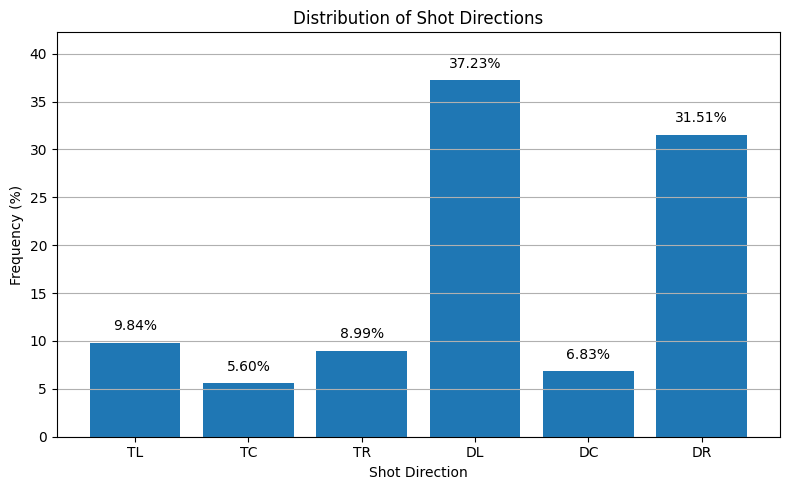

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Reload the dataset correctly
df = pd.read_csv("DataSetModel0NA6Alt.csv", sep=";", decimal=",")

# Mapping for Choice to zones
choice_labels = {
    1: 'TL',  # Top Left
    2: 'TC',  # Top Center
    3: 'TR',  # Top Right
    4: 'DL',  # Down Left
    5: 'DC',  # Down Center
    6: 'DR'   # Down Right
}

# Calculate normalized frequencies (percentages)
choice_counts = df['Choice'].value_counts(normalize=True).sort_index() * 100
choice_counts.index = choice_counts.index.map(choice_labels)

# Plot Distribution of Alternatives
plt.figure(figsize=(8, 5))
bars = plt.bar(choice_counts.index, choice_counts.values)

# Add percentage labels to bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f'{height:.2f}%', ha='center', va='bottom')

plt.title('Distribution of Shot Directions')
plt.xlabel('Shot Direction')
plt.ylabel('Frequency (%)')
plt.ylim(0, max(choice_counts.values) + 5)  # leave space for labels
plt.grid(axis='y')
plt.tight_layout()
plt.show()


plot "foot" vs direction (natural side logic)

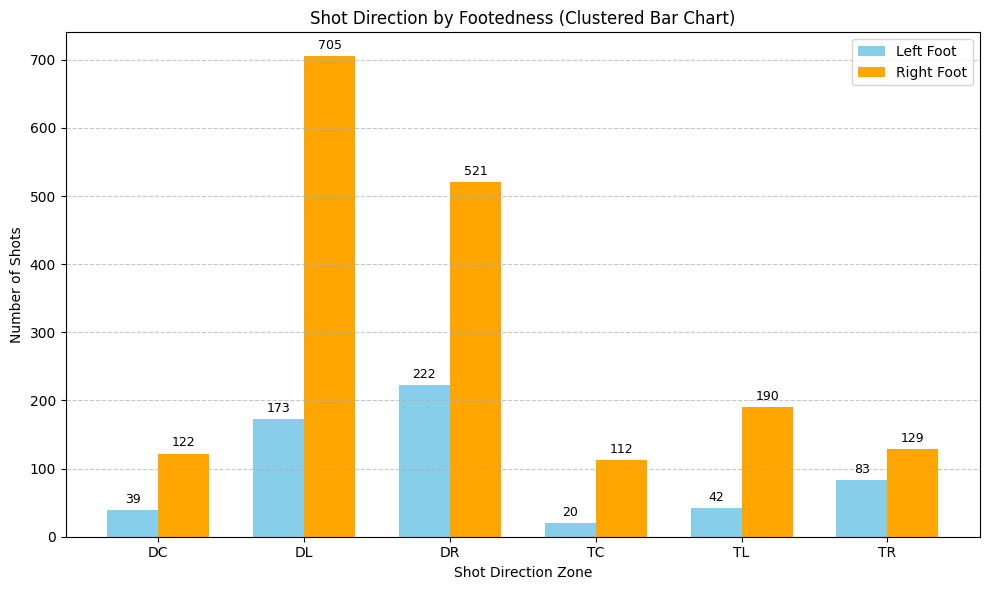

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Reload the dataset correctly
df = pd.read_csv("DataSetModel0NA6Alt.csv", sep=";", decimal=",")

# Map Choice to zone labels and foot to footedness labels
choice_labels = {1: 'TL', 2: 'TC', 3: 'TR', 4: 'DL', 5: 'DC', 6: 'DR'}
df['FootLabel'] = df['foot'].map({0: 'Left', 1: 'Right'})

# Compute counts for each (Foot, Choice) combination
foot_choice = pd.crosstab(df['FootLabel'], df['Choice'])

# Replace column numbers with zone labels
foot_choice.columns = foot_choice.columns.map(choice_labels)
foot_choice = foot_choice[sorted(foot_choice.columns)]  # Ensure TL to DR order

# Plot clustered bar chart
labels = foot_choice.columns
x = range(len(labels))

left_vals = foot_choice.loc['Left'] if 'Left' in foot_choice.index else [0]*len(labels)
right_vals = foot_choice.loc['Right'] if 'Right' in foot_choice.index else [0]*len(labels)

bar_width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar([i - bar_width/2 for i in x], left_vals, width=bar_width, label='Left Foot', color='skyblue')
bars2 = ax.bar([i + bar_width/2 for i in x], right_vals, width=bar_width, label='Right Foot', color='orange')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Customize axes
ax.set_xlabel('Shot Direction Zone')
ax.set_ylabel('Number of Shots')
ax.set_title('Shot Direction by Footedness (Clustered Bar Chart)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


goals misses

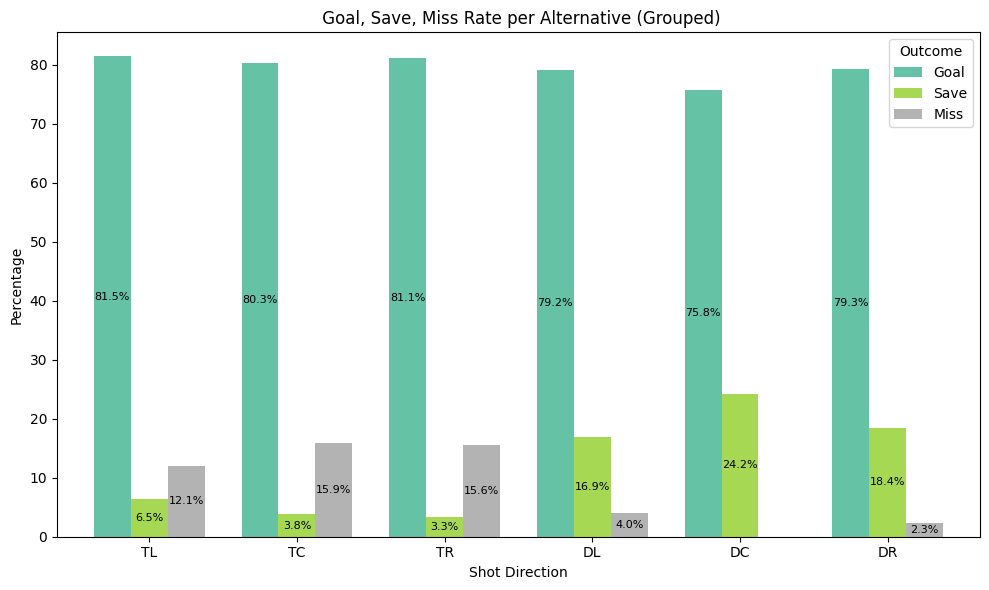

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("DataSetModelPlayer.csv", sep=None, engine="python", decimal=",")
df.columns = df.columns.str.strip()

# Normalize status values and extract relevant columns
df['Status'] = df['Status'].astype(str).str.lower().str.strip()
df['Alternative'] = df['Choice']

# Map outcome
outcome_map = {
    'goal': 'Goal',
    'saved': 'Save',
    'missed': 'Miss'
}
df['Outcome'] = df['Status'].map(outcome_map)

# Filter and clean
df = df[df['Alternative'].isin([1, 2, 3, 4, 5, 6])]
df = df.dropna(subset=['Outcome', 'Alternative'])

# Calculate percentages
summary = df.groupby(['Alternative', 'Outcome']).size().unstack().fillna(0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100
summary_pct = summary_pct[['Goal', 'Save', 'Miss']]  # Consistent order

# Custom mapping for x-axis labels
x_labels = {
    1: "TL",  # Top Left
    2: "TC",  # Top Center
    3: "TR",  # Top Right
    4: "DL",  # Down Left
    5: "DC",  # Down Center
    6: "DR"   # Down Right
}
summary_pct.index = summary_pct.index.map(x_labels)

# Plot grouped bar chart
ax = summary_pct.plot(kind='bar', figsize=(10, 6), colormap='Set2', width=0.75)
plt.title(" Goal, Save, Miss Rate per Alternative (Grouped)")
plt.xlabel("Shot Direction")
plt.ylabel("Percentage")
plt.legend(title='Outcome', loc='upper right')
plt.xticks(rotation=0)

# Add percentage labels inside bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_y() + height / 2),
                    ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()


In [32]:
import pandas as pd
import numpy as np

# Load the dataset with correct format
df = pd.read_csv("DataSetModel0NA6Alt.csv", sep=";", decimal=",")
database = db.Database("PenaltyData", df)

# Define variables
Choice = database.variables['Choice']

# Convert columns to numeric (important to handle issues from R CSV formats)
df["foot"] = pd.to_numeric(df["foot"], errors="coerce")
df["nmovGK"] = pd.to_numeric(df["nmovGK"], errors="coerce")

# Define the alternatives and their numeric codes
alt_code_map = {"TL": 1, "TC": 2, "TR": 3, "DL": 4, "DC": 5, "DR": 6}

# Compute means and t-statistics
results = []

for alt, code in alt_code_map.items():
    chosen = df[df["Choice"] == code]
    not_chosen = df[df["Choice"] != code]
    
    stats = {"Alternative": alt}
    for expl in ["foot", "nmovGK"]:
        mean_chosen = chosen[expl].mean()
        mean_not_chosen = not_chosen[expl].mean()
        diff = mean_chosen - mean_not_chosen
        pooled_std = np.sqrt(
            (chosen[expl].var(ddof=1) / len(chosen)) +
            (not_chosen[expl].var(ddof=1) / len(not_chosen))
        )
        t_stat = diff / pooled_std if pooled_std > 0 else np.nan

        stats[f"{expl}_mean_chosen"] = round(mean_chosen, 4)
        stats[f"{expl}_mean_not_chosen"] = round(mean_not_chosen, 4)
        stats[f"{expl}_t_stat"] = round(t_stat, 4)

    results.append(stats)

# Convert to DataFrame and display or save
results_df = pd.DataFrame(results)
print(results_df)

# Optional: save to CSV
# results_df.to_csv("choice_analysis_output.csv", index=False)


  Alternative  foot_mean_chosen  foot_mean_not_chosen  foot_t_stat  \
0          TL            0.8190                0.7474       2.6471   
1          TC            0.8485                0.7489       3.0510   
2          TR            0.6085                0.7689      -4.6070   
3          DL            0.8030                0.7257       4.3545   
4          DC            0.7578                0.7542       0.1013   
5          DR            0.7012                0.7789      -3.9411   

   nmovGK_mean_chosen  nmovGK_mean_not_chosen  nmovGK_t_stat  
0              1.7112                  1.6444         2.1073  
1              1.6288                  1.6523        -0.5247  
2              1.6981                  1.6463         1.5224  
3              1.6424                  1.6561        -0.6504  
4              1.6770                  1.6491         0.7271  
5              1.6272                  1.6619        -1.5683  


In [16]:
import numpy as np
import pandas as pd

# === 1. Load dataset ===
data = pd.read_csv("DataSetModel0NA6Alt.csv", sep=";", decimal=",")

# === 2. Alternatives ===
alternatives = {1: "TL", 2: "TC", 3: "TR", 4: "DL", 5: "DC", 6: "DR"}

# === 3. Final model coefficients (from your estimation) ===
asc = {1: 2.88, 2: 0.298, 3: 5.35, 4: 0.199, 5: 0.0, 6: 2.68}
b_foot = {1: 0.431, 2: 0.803, 3: -0.592, 4: 0.376, 5: 0.0, 6: -0.216}
b_moveGK = {1: -0.0617, 2: -0.131, 3: 0.0274, 4: 0.4, 5: 0.0, 6: -0.326}
b_GKS = {1: -0.160, 2: 0.018, 3: -0.589, 4: 0.219, 5: 0.0, 6: -0.137}
b_IS = {1: 0.454, 2: -0.305, 3: 0.851, 4: -0.294, 5: 0.0, 6: 0.232}
b_comL = {1: -0.147, 2: -0.483, 3: -0.123, 4: -0.743, 5: 0.0, 6: -0.068}
b_HGK = {1: -0.015, 2: 0.019, 3: 0.016, 4: 0.024, 5: 0.0, 6: 0.027}
b_dec = {1: 0.067, 2: -1.368, 3: 0.487, 4: 0.365, 5: 0.0, 6: 0.194}
b_lp = {1: -0.173, 2: -0.577, 3: -0.160, 4: 0.078, 5: 0.0, 6: 0.170}
b_latr = {1: 0.680, 2: 0.949, 3: 1.025, 4: 0.442, 5: 0.0, 6: 0.538}
b_ladr = {1: 0.094, 2: 0.049, 3: -0.421, 4: -0.198, 5: 0.0, 6: -0.226}
b_rnog = {1: 0.067, 2: -0.483, 3: 0.487, 4: -0.648, 5: 0.0, 6: 0.194}
b_solsbg = {1: 0.067, 2: 0.103, 3: 0.487, 4: 0.123, 5: 0.0, 6: 0.194}
b_nmovGK = {1: 0.067, 2: 0.010, 3: 0.487, 4: 0.045, 5: 0.0, 6: 0.194}
b_def = {1: 0.067, 2: 0.437, 3: 0.487, 4: 0.421, 5: 0.0, 6: 0.194}
b_sr1 = -1.100  # only for TL (alt 1)
b_sr3 = -0.700  # only for TR (alt 3)
b_perc = 0.329  # generic coefficient for perc1-6

# === 4. Compute utility for one observation ===
def compute_utilities(row):
    V = {}
    for alt in alternatives.keys():
        V[alt] = (
            asc[alt]
            + b_foot[alt] * row["foot"]
            + b_moveGK[alt] * row["moveGK"]
            + b_GKS[alt] * row["GKS"]
            + b_IS[alt] * row["IngSo"]
            + b_comL[alt] * row["comLea"]
            + b_HGK[alt] * row["HeiGK"]
            + b_dec[alt] * row["Dec"]
            + b_lp[alt] * row["lpbg"]
            + b_latr[alt] * row["la3"]
            + b_ladr[alt] * row["la6"]
            + b_rnog[alt] * row["rnoGroup"]
            + b_solsbg[alt] * row["Solsbg"]
            + b_nmovGK[alt] * row["nmovGK"]
            + b_def[alt] * row["def"]
            + b_perc * row[f"perc{alt}"]  # history variable per alt
        )
        # SRGK variables apply only to TL (1) and TR (3)
        if alt == 1:
            V[alt] += b_sr1 * row["SRGK1"]
        if alt == 3:
            V[alt] += b_sr3 * row["SRGK3"]
    return V

def compute_probabilities(V):
    expV = {alt: np.exp(v) for alt, v in V.items()}
    denom = sum(expV.values())
    return {alt: val / denom for alt, val in expV.items()}

# === 5. Predict highest probability alternative for each observation ===
results = []
for _, row in data.iterrows():
    V = compute_utilities(row)
    probs = compute_probabilities(V)
    best_alt = max(probs, key=probs.get)
    results.append({"actual": row["Choice"], "best_alt": best_alt})

df_results = pd.DataFrame(results)

# === 6. Table 7 aggregation ===
table7 = []
for alt_num, alt_name in alternatives.items():
    times_chosen = (df_results["actual"] == alt_num).sum()
    times_highest = (df_results["best_alt"] == alt_num).sum()
    times_correct = ((df_results["best_alt"] == alt_num) & (df_results["actual"] == alt_num)).sum()
    table7.append({
        "Alternative": alt_name,
        "Times chosen (db)": times_chosen,
        "Times highest probability": times_highest,
        "Times chosen when highest prob": times_correct
    })

table7_df = pd.DataFrame(table7)
table7_df.to_csv("table7.csv", index=False)
print(table7_df)


  Alternative  Times chosen (db)  Times highest probability  \
0          TL                232                          0   
1          TC                132                          0   
2          TR                212                       2358   
3          DL                878                          0   
4          DC                161                          0   
5          DR                743                          0   

   Times chosen when highest prob  
0                               0  
1                               0  
2                             212  
3                               0  
4                               0  
5                               0  


 generate visualizations

In [20]:
import pandas as pd

df = pd.read_csv("DataSetModel0NA6Alt.csv", delimiter="\t", decimal=",")
print(df.columns.tolist())


['ID;ppos;def;mf;st;foot;Age;RepGK;HeiGK;ClubNT;tpos;tup0;tup;tmid0;tmid;tbot0;tbot;otpos;oup0;oup;omid0;omi;obot0;obot;fav;favU;favF;loc;locH;locN;locA;rno;rno1;rno2;rnoGroup;rnoLS;rnoQF;rnoSF;rnoF;rko;comp;comLea;comCup;comECC;comQuali;comNTC;comFrie;SpecM;Imp;Importantness Game;IngSo;iLdbb;bb3;bb2o;bb2;bb1;d0;il1;il2;Min;Minf30;Minf3;Mins30;Mins3;Mint30;Mint3;Min900;Min90;Dec;GKSo;GKS;moveGK;notmovingGK;nmovGK;cjGrey;cjBlack;cjBlue;cjGreen;cjYellow;cjOrange;cjRed;la1;la2;la3;la4;la5;la6;lpbg;lGKd;tlpmon;Stlsbg;SlGKd;Solsbg;SR1;SRGK1;SR2;SRGK2;SR3;SRGK3;SR4;SRGK4;SR5;SRGK5;SR6;SRGK6;MP1;MPGK1;MP2;MPGK2;MP3;MPGK3;MP4;MPGK4;MP5;MP6;MPGK6;perc1;perc2;perc3;perc4;perc5;perc6;av_1;av_2;av_3;av_4;av_5;av_6;move;still;Choice']


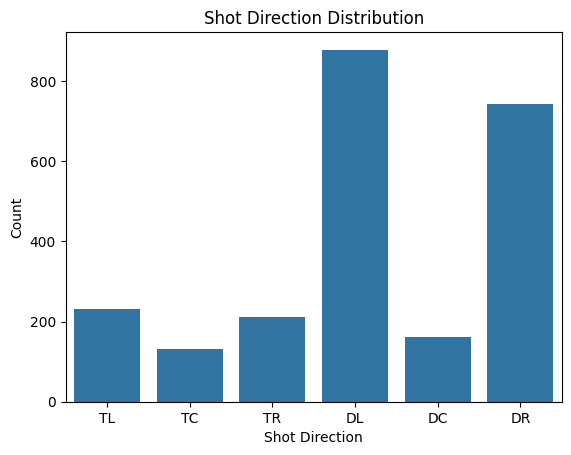

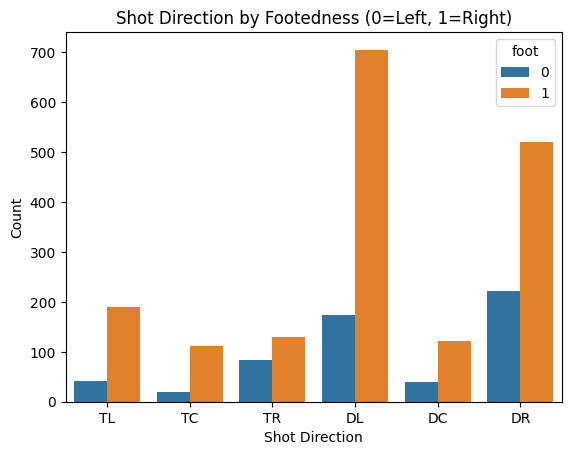

c:\Users\varsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Prediction Accuracy: 39.36%


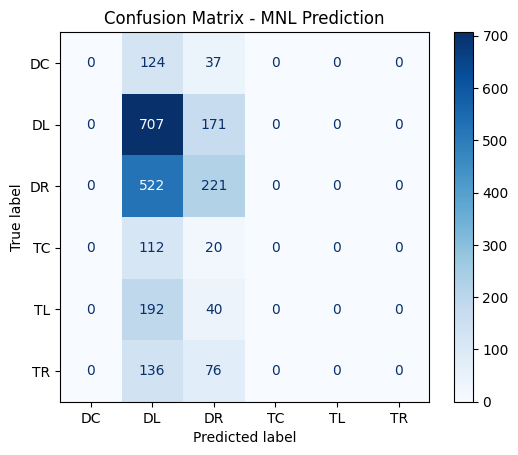

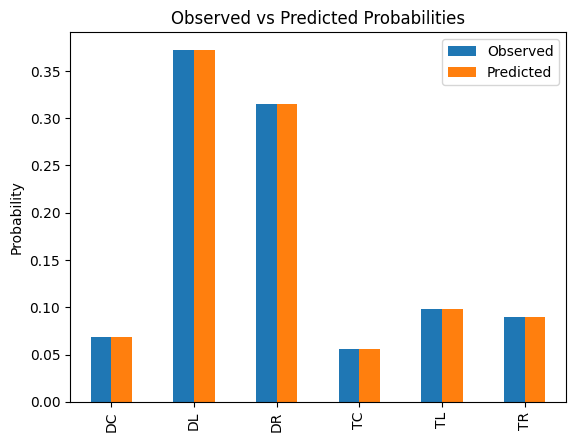

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------------
# 1. Load Dataset Correctly
# -------------------------
df = pd.read_csv("DataSetModel0NA6Alt.csv", delimiter=";", decimal=",")

# Strip any spaces in column names
df.columns = df.columns.str.strip()

# Ensure Choice column exists
if "Choice" not in df.columns:
    raise KeyError("No 'Choice' column found. Check dataset headers again.")

# -------------------------
# 2. Map Choice to Shot Direction (thesis alternatives)
# -------------------------
alt_map = {1: "TL", 2: "TC", 3: "TR", 4: "DL", 5: "DC", 6: "DR"}
df["shot_direction"] = df["Choice"].map(alt_map)

# Drop rows missing critical values
df = df.dropna(subset=["shot_direction", "foot", "HeiGK"])

# -------------------------
# 3. Visualizations Similar to Thesis
# -------------------------

# (a) Shot direction distribution
sns.countplot(x="shot_direction", data=df, order=["TL","TC","TR","DL","DC","DR"])
plt.title("Shot Direction Distribution")
plt.xlabel("Shot Direction")
plt.ylabel("Count")
plt.show()

# (b) Shot direction by footedness
sns.countplot(x="shot_direction", hue="foot", data=df, order=["TL","TC","TR","DL","DC","DR"])
plt.title("Shot Direction by Footedness (0=Left, 1=Right)")
plt.xlabel("Shot Direction")
plt.ylabel("Count")
plt.show()

# -------------------------
# 4. Multinomial Logistic Regression (MNL) using scikit-learn
# -------------------------

# Features used (can expand based on thesis)
features = ["foot", "HeiGK", "Dec", "nmovGK"]
X = pd.get_dummies(df[features], drop_first=True)
y = df["shot_direction"]

# Fit model
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
model.fit(X, y)

# Predictions
df["predicted_direction"] = model.predict(X)
pred_probs = model.predict_proba(X)
class_labels = model.classes_

# -------------------------
# 5. Accuracy & Confusion Matrix
# -------------------------
accuracy = (df["predicted_direction"] == df["shot_direction"]).mean() * 100
print(f"Prediction Accuracy: {accuracy:.2f}%")

cm = confusion_matrix(df["shot_direction"], df["predicted_direction"], labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - MNL Prediction")
plt.show()

# -------------------------
# 6. Observed vs Predicted Probabilities
# -------------------------
observed = df["shot_direction"].value_counts(normalize=True).reindex(class_labels)
predicted = pd.DataFrame(pred_probs, columns=class_labels).mean()

comparison = pd.DataFrame({"Observed": observed, "Predicted": predicted})
comparison.plot(kind="bar")
plt.title("Observed vs Predicted Probabilities")
plt.ylabel("Probability")
plt.show()


Split the dataset → training for estimation, testing for prediction.

Train the MNL model on training data.

Predict probabilities on unseen test data.

Compare observed vs predicted (like the thesis does after estimation).

Model is estimated on 70% of data

Evaluated on unseen 30% test data

c:\Users\varsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Prediction Accuracy (Test Set): 41.53%


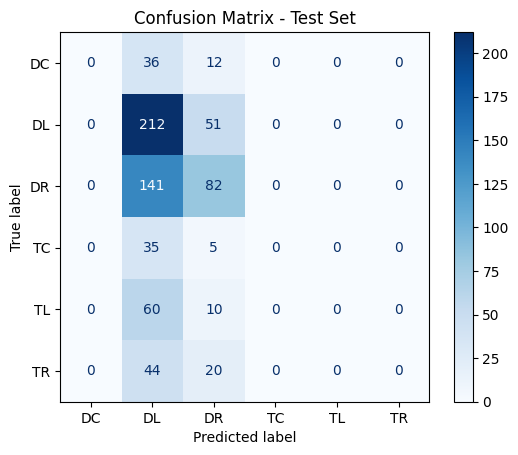

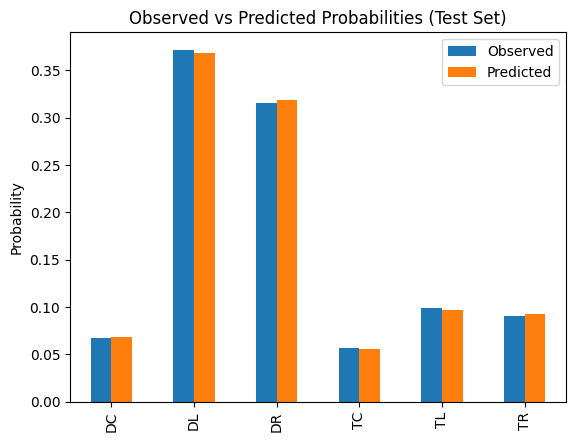

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Load dataset correctly
df = pd.read_csv("DataSetModel0NA6Alt.csv", delimiter=";", decimal=",")
df.columns = df.columns.str.strip()
alt_map = {1: "TL", 2: "TC", 3: "TR", 4: "DL", 5: "DC", 6: "DR"}
df["shot_direction"] = df["Choice"].map(alt_map)
df = df.dropna(subset=["shot_direction", "foot", "HeiGK"])

# Features and target
features = ["foot", "HeiGK", "Dec", "nmovGK"]
X = pd.get_dummies(df[features], drop_first=True)
y = df["shot_direction"]

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- Fit model on training data ---
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# --- Predict on test data ---
y_pred = model.predict(X_test)
y_pred_probs = model.predict_proba(X_test)
class_labels = model.classes_

# --- Accuracy ---
accuracy = (y_pred == y_test).mean() * 100
print(f"Prediction Accuracy (Test Set): {accuracy:.2f}%")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

# --- Observed vs Predicted (on test set) ---
observed = y_test.value_counts(normalize=True).reindex(class_labels)
predicted = pd.DataFrame(y_pred_probs, columns=class_labels).mean()
comparison = pd.DataFrame({"Observed": observed, "Predicted": predicted})
comparison.plot(kind="bar")
plt.title("Observed vs Predicted Probabilities (Test Set)")
plt.ylabel("Probability")
plt.show()


In [1]:

# Map player positions
pos_map = {0: "Goalkeeper", 1: "Defender", 2: "Midfielder", 3: "Striker"}
df["role"] = df["ppos"].map(pos_map)

# Counts by player role
role_counts = df["role"].value_counts()

# In-match vs shootout counts
in_match_count = (df["IngSo"] == 0).sum()
shootout_count = (df["IngSo"] == 1).sum()

# Footedness counts
left_foot_count = (df["foot"] == 0).sum()
right_foot_count = (df["foot"] == 1).sum()

# Shot direction mapping
choice_map = {1: "TL", 2: "TC", 3: "TR", 4: "DL", 5: "DC", 6: "DR"}
df["choice_name"] = df["Choice"].map(choice_map)
choice_perc = df["choice_name"].value_counts(normalize=True) * 100

# Goalkeeper positioning
gk_pos_counts = df["GKS"].value_counts(normalize=True) * 100  # 1=Left, 2=Center, 3=Right
labels_gk_pos = ["Center", "Right", "Left"]
values_gk_pos = [gk_pos_counts.get(2, 0), gk_pos_counts.get(3, 0), gk_pos_counts.get(1, 0)]

# Goalkeeper movement (nmovGK: 1=Moving, 2=Not Moving)
gk_move_counts = df["nmovGK"].value_counts(normalize=True) * 100
labels_gk_move = ["Not Moving", "Moving"]
values_gk_move = [gk_move_counts.get(2.0, 0), gk_move_counts.get(1.0, 0)]

# Data for plots
labels_roles = role_counts.index.tolist()
values_roles = role_counts.values
labels_context = ["In-Match", "Shootout"]
values_context = [in_match_count, shootout_count]
labels_foot = ["Left-footed", "Right-footed"]
values_foot = [left_foot_count, right_foot_count]
labels_choice = choice_perc.index.tolist()
values_choice = choice_perc.values

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# Role distribution
axs[0, 0].bar(labels_roles, values_roles, color='skyblue')
axs[0, 0].set_title("Penalty Attempts by Player Role")
axs[0, 0].set_ylabel("Count")

# Match context
axs[0, 1].bar(labels_context, values_context, color='lightgreen')
axs[0, 1].set_title("Penalty Attempts by Match Context")
axs[0, 1].set_ylabel("Count")

# Footedness
axs[1, 0].bar(labels_foot, values_foot, color='orange')
axs[1, 0].set_title("Penalty Attempts by Footedness")
axs[1, 0].set_ylabel("Count")

# Choice distribution
axs[1, 1].bar(labels_choice, values_choice, color='purple')
axs[1, 1].set_title("Shot Direction Choices (%)")
axs[1, 1].set_ylabel("Percentage")

# Goalkeeper position
axs[2, 0].bar(labels_gk_pos, values_gk_pos, color='red')
axs[2, 0].set_title("Goalkeeper Positioning at Kick (%)")
axs[2, 0].set_ylabel("Percentage")

# Goalkeeper movement
axs[2, 1].bar(labels_gk_move, values_gk_move, color='teal')
axs[2, 1].set_title("Goalkeeper Movement at Kick (%)")
axs[2, 1].set_ylabel("Percentage")

plt.tight_layout()
plt.show()


NameError: name 'df' is not defined